In [1]:
import numpy as np
import h5py
import time
import inspect

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from helpers.gw_shapes import *
from dataset_generation.gw_class_gen import *
from helpers.config import *
from dataset_generation.noise_psd_gen import *

from lisaglitch import LPFLibraryGlitch, ShapeletGlitch, HDF5Glitch, Glitch
from lisainstrument import Instrument

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

/opt/anaconda3/envs/gwaves_lisa_py311/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [123]:
with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']

orb_duration = orb_size * orb_dt
pipe = {'t0': orb_t0+ 0.01*orb_duration, 'dt': 0.25,'size': int(10 * 3600 / 0.25),
        't_inj': 5 * 3600}

In [124]:
gws, glitches = [], []
run_simulation(gws, glitches, pipe,
            None, None, orbits_path,
            simulation_path,
            disable_noise=['test-mass', 'oms'],
            seed=42)
raw_dict = run_tdi(simulation_path, pipe)

Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


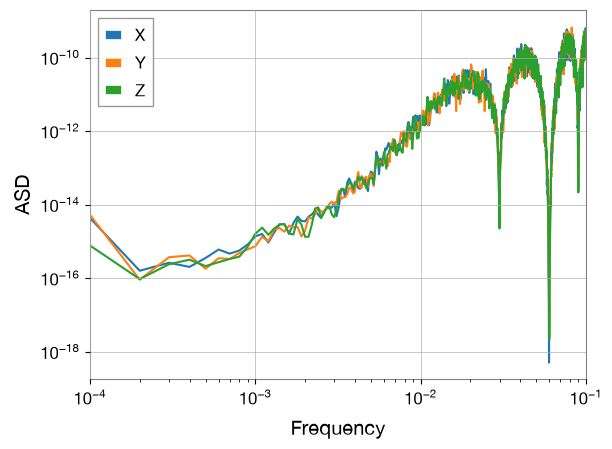

In [5]:
for key in raw_dict.keys():
    f_psd, psd = estimate_psd(raw_dict[key].value, 1/pipe['dt'], nperseg=1e4/pipe['dt'], noverlap=None)

    plt.plot(f_psd, psd, label=key)
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-4, 1e-1)
plt.xlabel('Frequency')
plt.ylabel('ASD')
plt.legend()
plt.show()

In [6]:
gws, glitches = [], []
run_simulation(gws, glitches, pipe,
            None, None, orbits_path,
            simulation_path,
            disable_noise=['laser', 'test-mass', 'oms'],
            seed=42)
raw_dict = run_tdi(simulation_path, pipe)

Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


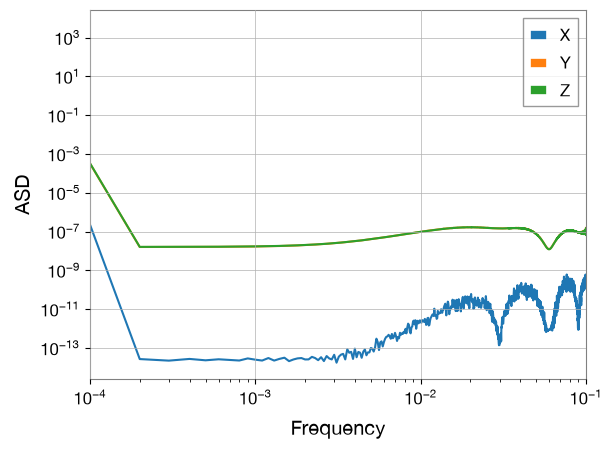

In [7]:
for key in raw_dict.keys():
    f_psd, psd = estimate_psd(raw_dict[key].value, 1/pipe['dt'], nperseg=1e4/pipe['dt'], noverlap=None)

    plt.plot(f_psd, psd, label=key)
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-4, 1e-1)
plt.xlabel('Frequency')
plt.ylabel('ASD')
plt.legend()
plt.show()

## Ollie's method

In [2]:
import datetime
import logging

from lisainstrument import Instrument
from lisaorbits import OEMOrbits

from pytdi import Data
from pytdi.intervar import compute_etas
from pytdi.michelson import compute_factorized_michelson

In [3]:
def build_orbits():
    """Generate the ESA trailing-orbit file. Returns the science-run start time."""
    years_commissioning = 2
    orbits = OEMOrbits.from_included("esa-trailing")

    orbits_dt = 1e5
    orbits_duration = datetime.timedelta(
        days=years_commissioning * 365
    ).total_seconds()  # ~ 2 years
    orbits_size = int(orbits_duration / orbits_dt)
    # Start the science run after the commissioning period.
    orbits_t0 = orbits.t_start + orbits_duration

    orbits.write(
       str(DIST / 'orbits' / 'orbits_trial.h5'), dt=orbits_dt, size=orbits_size, t0=orbits_t0, mode="w"
    )
    return orbits_t0


In [42]:
def build_instrument_config(orbits_t0, hours=10, gw_path=None, glitch_path=None):
    """Assemble the lisainstrument configuration dict for the 30-day run."""
    instru_t0 = orbits_t0 + 100.0  # s
    instru_dt = 0.25
    instru_duration = hours * 3600
    instru_size = int(instru_duration / instru_dt)

    instru_config = {
        # Random seed
        "seed": 0,
        # Sampling parameters
        "size": instru_size,
        "dt": instru_dt,
        "t0": instru_t0,
        # Physics simulation sampling and filtering
        "physics_upsampling": 4,
        "aafilter": ("kaiser", 240, 1.1, 2.9),
        "noises_f_min_hz": 5e-6,
        # Telemetry sampling
        "telemetry_downsampling": 86400 * 4,
        "initial_telemetry_size": 0,
        # Inter-spacecraft propagation
        "orbits": str(DIST / 'orbits' / 'orbits_trial.h5'),
        "orbit_dataset": "tcb/ltt",
        "gws": gw_path,
        "interpolation": ("lagrange", 31),
        # Artifacts
        "glitches": glitch_path,
        # Laser locking and frequency plan
        "lock": "six",
        "fplan": "static",
        "laser_asds": 0.0,
        "laser_shape": "white",
        "central_freq": 2.816e14,
        "offset_freqs": {
            "12": 0.0,
            "23": 11e6,
            "31": 7.5e6,
            "13": 16e6,
            "32": -12e6,
            "21": -7e6,
        },
        # Laser phase modulation
        "modulation_asds": 0.0,
        "modulation_freqs": 0.0,
        "tdir_modulations": None,
        # Clocks
        "clock_asds": 0.0,
        "clock_offsets": 0.0,
        "clock_freqoffsets": 0.0,
        "clock_freqlindrifts": 0.0,
        "clock_freqquaddrifts": 0.0,
        "clock_f_min_hz": 5e-6,
        # Clock inversion
        "clockinv_tolerance": 1e-10,
        "clockinv_maxiter": 5,
        # Optical pathlength noises
        "backlink_asds": 0.0,
        "backlink_fknees": 0.0,
        "testmass_asds": 3.0e-15,
        "testmass_fknees": 0.4e-3,
        "testmass_fbreak": 8e-3,
        "testmass_frelax": 0.0,
        "testmass_shape": "original",
        "oms_asds": (15.0e-12, 0.0, 0.0, 0.0, 0.0, 0.0),
        "oms_fknees": 2e-3,
        # MOC time correlation
        "moc_time_correlation_asds": 0.0,
        # Tilt-to-length (TTL)
        "ttl_coeffs": (0.0, 0.0, 0.0, 0.0),
        "sc_angular_jitter_asds": (0.0, 0.0, 0.0),
        "sc_angular_jitter_fknees": (0.0, 0.0, 0.0),
        "mosa_angular_jitter_asds": (0.0, 0.0),
        "mosa_angular_jitter_fknees": (0.0, 0.0),
        "mosa_angles": {
            "12": 30, "23": 30, "31": 30, "13": -30, "32": -30, "21": -30
        },
        "dws_asds": 0.0,
        # Lateral jitters
        "mosa_longitudinal_jitter_asds": 0.0,
        # Pseudo-ranging
        "ranging_biases": 0,
        "ranging_asds": 0.0,
        "prn_ambiguity": None,
        # Electronic delays
        "electro_delays": (0, 0, 0),
    }
    return instru_config

In [43]:
amp = 4e-13
beta = 432
inj_point = 'tm_12'
orbits_t0 = build_orbits()
t0 = orbits_t0 + 100

instru_t0 = orbits_t0 + 100.0  # s
instru_dt = 0.25
instru_duration = 10 * 3600
instru_size = int(instru_duration / instru_dt)

if os.path.exists(glitch_path):
    os.remove(glitch_path)

glitch = IntegratedShapeletGlitch(level=2*amp*beta, beta=beta, 
                                    inj_point=inj_point, t_inj=5*3600 + t0)

glitch.write(path=glitch_path, mode="a", t0=t0, size=instru_size, dt=instru_dt)

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [44]:
instru_config = build_instrument_config(orbits_t0, hours=10, gw_path=None, glitch_path=None)
instru = Instrument(**instru_config)
instru.export_hdf5(simulation_path, overwrite=True)

Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz


In [45]:
TDI_ORDER = 45
data = Data.from_instrument(simulation_path)
eta_vars = compute_etas(data, order=TDI_ORDER, unit="frequency")


You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [46]:
raw_dict = {}
channels = ['X', 'Y', 'Z']

for i in range(len(channels)):
    raw_dict[channels[i]] = compute_factorized_michelson(
        data, etas=eta_vars, order=TDI_ORDER, generation=2, rot=i, unit="frequency")

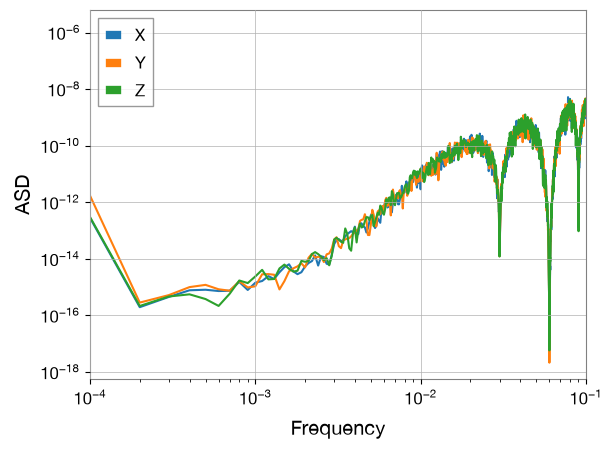

In [47]:
channels = ['X', 'Y', 'Z']

for channel in channels:
    f_psd, psd = estimate_psd(raw_dict[channel], 1/instru_dt, nperseg=1e4/instru_dt, noverlap=None)

    plt.plot(f_psd, psd, label=channel)
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-4, 1e-1)
plt.xlabel('Frequency')
plt.ylabel('ASD')
plt.legend()
plt.show()

In [14]:
def generate_qscan(tdi_dict, channel, dt, event, 
                   frange, trange, Q, resolution):

    signal = TimeSeries(tdi_dict[channel], dt=dt, t0=0)
    
    time_secs = signal.times.value
    time_hrs = time_secs/3600
    
    index = np.where((time_hrs <= event/3600 + trange[1]) & (time_hrs >= event/3600 + trange[0]))[0]
    sigslice = signal[index].value
    timeslice = signal[index].times.value
    
    t_arr, f_arr, QT = q_transform(timeslice, sigslice, Q=Q, resolution=resolution,
                        frange=frange, trange=(np.min(timeslice),np.max(timeslice)))

    return t_arr, f_arr, QT

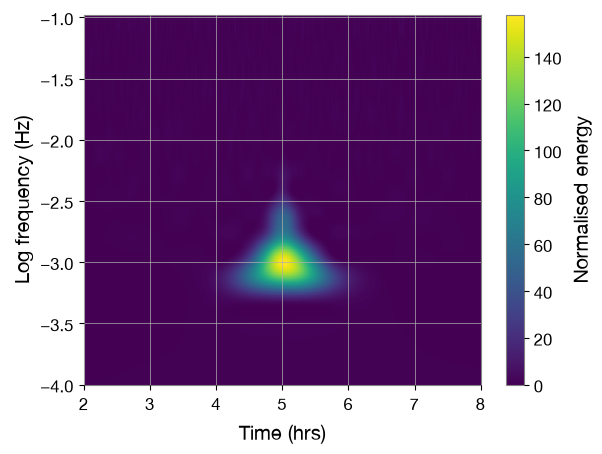

In [19]:
t_axis, f_axis, QT = generate_qscan(raw_dict, 'X', instru_dt, 5*3600, resolution=256,
                             frange=(1e-4, 1e-1), trange=(-3, 3), Q=6)

plt.imshow(QT, extent=[t_axis[0]/3600, t_axis[-1]/3600, np.log10(f_axis[0]), np.log10(f_axis[-1])],\
     aspect='auto', origin='lower')

plt.xlabel('Time (hrs)')
plt.ylabel('Log frequency (Hz)')
plt.colorbar(label='Normalised energy')
plt.show()